Mel shape: (80, 63)
Log-Mel shape: (80, 63)


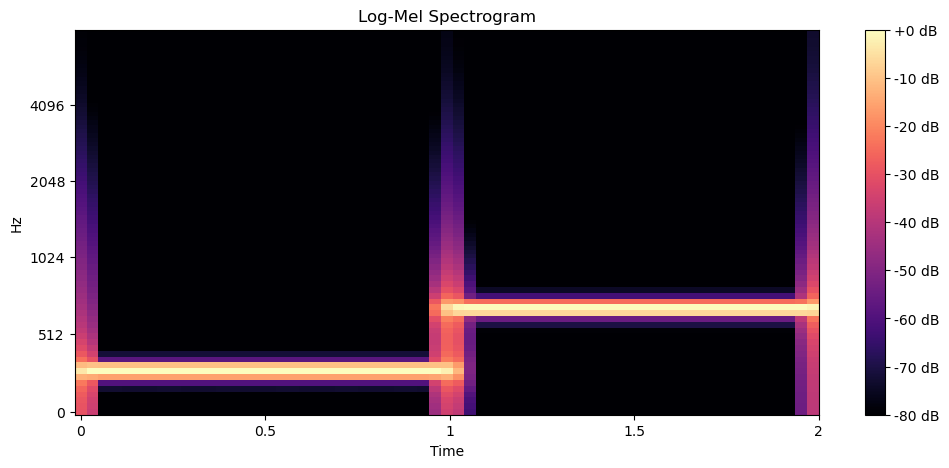

In [1]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

sample_rate = 16000
duration = 2.0

N = int(
    sample_rate * duration
)

time = np.arange(N) / sample_rate

# First second -> 300 Hz
# Second second -> 700 Hz
signal = np.zeros(N)

signal[:sample_rate] = np.sin(
    2 * np.pi * 300 * time[:sample_rate]
)

signal[sample_rate:] = np.sin(
    2 * np.pi * 700 * time[sample_rate:]
)

# Mel power spectrogram
mel_spectrogram = librosa.feature.melspectrogram(
    y=signal,
    sr=sample_rate,
    n_fft=2048,
    hop_length=512,
    win_length=2048,
    n_mels=80,
    fmin=0,
    fmax=8000,
    power=2.0
)

# Convert power -> dB
log_mel = librosa.power_to_db(
    mel_spectrogram,
    ref=np.max
)

print("Mel shape:", mel_spectrogram.shape)
print("Log-Mel shape:", log_mel.shape)

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    log_mel,
    sr=sample_rate,
    hop_length=512,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(
    format="%+2.0f dB"
)

plt.title("Log-Mel Spectrogram")

plt.show()

In [2]:
"""
Those vertical lines are transient/boundary artifacts from the abrupt way we constructed the signal.
We made:
- 0–1 s: 300 Hz
- 1–2 s: 700 Hz
with an immediate switch at exactly 1 s.
So around:

t=1.0s the waveform can jump suddenly from whatever amplitude the 300 Hz sine happens to have to whatever amplitude the 700 Hz sine starts with.
A sudden change in time contains a broad range of frequencies, so in the spectrogram it appears as a vertical stripe across many Mel bands.
The same idea applies near 0 s and 2 s because the signal begins and ends abruptly.
So
horizontal structures -> steady frequencies

vertical structures -> sudden time-domain changes transients
If you fade the signal in/out and smoothly crossfade the 300 Hz and 700 Hz sections, those vertical boundary lines become much weaker.
"""

'\nThose vertical lines are transient/boundary artifacts from the abrupt way we constructed the signal.\nWe made:\n- 0–1 s: 300 Hz\n- 1–2 s: 700 Hz\nwith an immediate switch at exactly 1 s.\nSo around:\n\nt=1.0s the waveform can jump suddenly from whatever amplitude the 300 Hz sine happens to have to whatever amplitude the 700 Hz sine starts with.\nA sudden change in time contains a broad range of frequencies, so in the spectrogram it appears as a vertical stripe across many Mel bands.\nThe same idea applies near 0 s and 2 s because the signal begins and ends abruptly.\nSo\nhorizontal structures -> steady frequencies\n\nvertical structures -> sudden time-domain changes transients\nIf you fade the signal in/out and smoothly crossfade the 300 Hz and 700 Hz sections, those vertical boundary lines become much weaker.\n'